In [ ]:
# 3rd party imports
import torch
from torch import nn as NN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

# local imports
from neural_network import StockModel
from dataset_handler import DataManager
from binance_api.indicators import ADX, RSI, EMA

In [ ]:
# --------------------------------------------------
# GLOBAL SPEED SETTINGS
# --------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True

In [3]:
# --------------------------------------------------
# HYPER PARAMETERS (Modify these as needed)
# --------------------------------------------------

# Model architecture
INPUT_SIZE = 8
LSTM_HIDDEN_SIZE = 32
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.4
FC1_OUT_FEATURES = 128
FC_DROPOUT = 0.4
NUM_CLASSES = 3

# Training parameters
EPOCHS = 150
BATCH_SIZE = 256
LEARNING_RATE = 0.001
GRADIENT_CLIP = 1.0
VAL_PATIENCE = 10  # Early stopping patience

# Loss weights for [Neutral, Up, Down]
CROSS_ENTROPY_LOSS_WEIGHTS = [1, 1, 1]

# Model save path
MODEL_SAVE_PATH = "trained_model.pth"

In [ ]:
# -------------------------------------
# PROCESS RAW FILE
# -------------------------------------

# the raw csv file
csv_file_name = "XRPUSDT_15m_Jan_to_Dec_2025.csv"

# create indicators
ema_1 = EMA(20)
ema_2 = EMA(50)
rsi = RSI(14)
adx = ADX(14)

# create datafram manager
dataframe_manager = DataManager(
    csv_file=csv_file_name,
    device=DEVICE,
    indicators=[ema_1, ema_2, rsi, adx]
)

# columns to perform actions on
cols_to_scale_log = ["open", "volume", "future_min", "future_max"]
scalable_cols = ["open", "volume", "future_min", "future_max", "ema_0_diff", "ema_1_diff"]
cols_to_extract = ["open", "volume", "ema_0_diff", "ema_1_diff", "rsi_2", "adx_3", "return", "future_min", "future_max", "label"]

# perform action
dataframe_manager.preprocess(threshold=0.003, look_ahead=8)
dataframe_manager.perform_scaling(scalable_cols, cols_to_scale_log)

# save
dataframe_manager.df[cols_to_extract].to_csv("XRP_USDT.csv", index=False)

In [4]:
# -------------------------------------
# USE PROCESSED FILE
# -------------------------------------

# create dataframe manager
dataframe_manager = DataManager(
    csv_file="XRP_USDT.csv",
    device=DEVICE,
)

# the columns to use (direction-only, no min/max prediction)
feature_cols = ["open", "volume", "ema_0_diff", "ema_1_diff", "rsi_2", "adx_3", "return", "label"]
target_col = ["label"]

# get training and testing tensors
trainX, trainY = dataframe_manager.get_train_tensors(
    feature_col=feature_cols, target_col=target_col
)
testX, testY = dataframe_manager.get_test_tensors(
    feature_col=feature_cols, target_col=target_col
)

# setup training dataset
train_dataset = TensorDataset(trainX, trainY)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

print(f"Train samples: {len(trainX)}, Test samples: {len(testX)}")

Train samples: 54968, Test samples: 13599


In [5]:
# --------------------------------------------------
# TRAIN WITH EARLY STOPPING
# --------------------------------------------------

# create the model for direction classification
model = StockModel(
    input_size=INPUT_SIZE,
    lstm_layer_out=LSTM_HIDDEN_SIZE,
    lstm_layer_num=LSTM_NUM_LAYERS,
    lstm_dropout=LSTM_DROPOUT,
    fc1_out=FC1_OUT_FEATURES,
    fc_dropout=FC_DROPOUT,
    num_classes=NUM_CLASSES,
    device=DEVICE,
)

# create optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# create learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=5
)

# create loss function with class weights
class_weights = torch.tensor(CROSS_ENTROPY_LOSS_WEIGHTS, dtype=torch.float, device=DEVICE)
criterion = NN.CrossEntropyLoss(weight=class_weights)

# create a scaler for mixed precision
scaler = torch.amp.GradScaler(enabled=(DEVICE == "cuda"))

# early stopping variables
best_val_accuracy = 0.0
patience_counter = 0
best_model_state = None

# get actual directions for validation
actual_directions = testY[:, 0, 0].cpu().tolist()

# train loop
for epoch in range(EPOCHS):

    # switch model to training
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # get batches
    for x_batch, y_batch in train_loader:

        # reset the gradient
        optimizer.zero_grad(set_to_none=True)

        # use float16 or float32 based on the device
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE == "cuda")):

            # model returns direction logits only
            direction_pred = model(x_batch)

            # get labels (label is now at index 0)
            labels = y_batch[:, 0, 0].long()

            # calculate loss
            loss = criterion(direction_pred, labels)

        # backward pass
        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)

        # take a step
        scaler.step(optimizer)
        scaler.update()

        # track metrics
        total_loss += loss.item()
        preds = direction_pred.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # calculate average loss
    avg_loss = total_loss / len(train_loader)

    # calculate train accuracy
    train_accuracy = correct / total

    # step scheduler
    scheduler.step(avg_loss)

    # === VALIDATION ===
    model.eval()
    direction_preds = []
    
    with torch.no_grad():
        for i in range(0, len(testX), BATCH_SIZE):
            x_batch = testX[i : i + BATCH_SIZE]
            direction_pred = model(x_batch)
            preds = direction_pred.argmax(dim=1).cpu().tolist()
            direction_preds.extend(preds)

    # calculate validation accuracy
    validation_accuracy = sum(
        p == a for p, a in zip(direction_preds, actual_directions)
    ) / len(actual_directions)

    # === EARLY STOPPING CHECK ===
    if validation_accuracy > best_val_accuracy:
        best_val_accuracy = validation_accuracy
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    # log to console
    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] Loss: {avg_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} Val Acc: {validation_accuracy:.4f}"
    )

    # if patience is greater than tolerable
    if patience_counter >= VAL_PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model with validation accuracy: {best_val_accuracy:.4f}")

Epoch [1/150] Loss: 0.9256 Train Acc: 0.5746 Val Acc: 0.7098
Epoch [2/150] Loss: 0.7533 Train Acc: 0.7097 Val Acc: 0.7140
Epoch [3/150] Loss: 0.7285 Train Acc: 0.7121 Val Acc: 0.7134
Epoch [4/150] Loss: 0.7200 Train Acc: 0.7145 Val Acc: 0.7127
Epoch [5/150] Loss: 0.7143 Train Acc: 0.7145 Val Acc: 0.7120
Epoch [6/150] Loss: 0.7082 Train Acc: 0.7162 Val Acc: 0.7123
Epoch [7/150] Loss: 0.7039 Train Acc: 0.7174 Val Acc: 0.7106
Epoch [8/150] Loss: 0.6961 Train Acc: 0.7177 Val Acc: 0.7146
Epoch [9/150] Loss: 0.6899 Train Acc: 0.7194 Val Acc: 0.7148
Epoch [10/150] Loss: 0.6819 Train Acc: 0.7202 Val Acc: 0.7126
Epoch [11/150] Loss: 0.6757 Train Acc: 0.7206 Val Acc: 0.7163
Epoch [12/150] Loss: 0.6705 Train Acc: 0.7212 Val Acc: 0.7161
Epoch [13/150] Loss: 0.6629 Train Acc: 0.7222 Val Acc: 0.7184
Epoch [14/150] Loss: 0.6563 Train Acc: 0.7240 Val Acc: 0.7162
Epoch [15/150] Loss: 0.6535 Train Acc: 0.7246 Val Acc: 0.7195
Epoch [16/150] Loss: 0.6505 Train Acc: 0.7253 Val Acc: 0.7216
Epoch [17/150] Lo

In [6]:
# --------------------------------------------------
# FINAL EVALUATION
# --------------------------------------------------

# switch model for inference
model.eval()
direction_preds = []

# with no gradient
with torch.no_grad():

    # iterate
    for i in range(0, len(testX), BATCH_SIZE):

        # get current batch
        x_batch = testX[i : i + BATCH_SIZE]

        # model returns direction logits only
        direction_pred = model(x_batch)

        # get predicted class
        preds = direction_pred.argmax(dim=1).cpu().tolist()
        direction_preds.extend(preds)

# calculate final accuracy
actual_directions = testY[:, 0, 0].cpu().tolist()
final_accuracy = sum(p == a for p, a in zip(direction_preds, actual_directions)) / len(actual_directions)
print(f"Final Test Accuracy: {final_accuracy:.4f}")

Final Test Accuracy: 0.7812


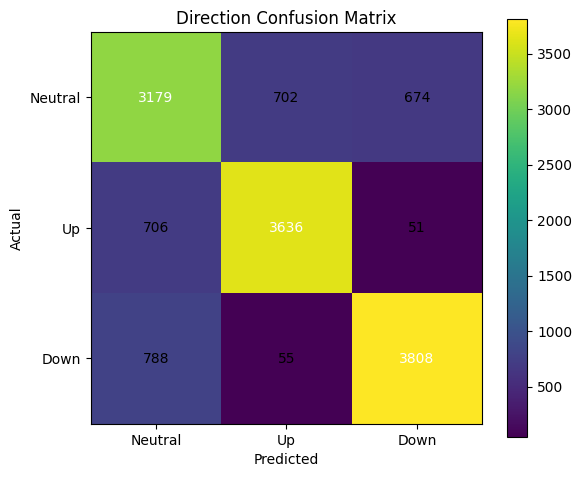

In [7]:
# --------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------

# class names
class_names = ["Neutral", "Up", "Down"]

# force fixed class order
cm = confusion_matrix(actual_directions, direction_preds, labels=[0, 1, 2])

# create figure
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

# colorbar
fig.colorbar(im, ax=ax)

# ticks & tick labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# labels
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Direction Confusion Matrix")

# write values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

# layout
plt.tight_layout()
plt.show()

In [8]:
# --------------------------------------------------
# SAVE MODEL
# --------------------------------------------------

# save model state dict
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# optionally save full checkpoint with hyperparameters
checkpoint = {
    "model_state_dict": model.state_dict(),
    "hyperparameters": {
        "INPUT_SIZE": INPUT_SIZE,
        "LSTM_HIDDEN_SIZE": LSTM_HIDDEN_SIZE,
        "LSTM_NUM_LAYERS": LSTM_NUM_LAYERS,
        "LSTM_DROPOUT": LSTM_DROPOUT,
        "FC1_OUT_FEATURES": FC1_OUT_FEATURES,
        "FC_DROPOUT": FC_DROPOUT,
        "NUM_CLASSES": NUM_CLASSES,
    },
    "best_val_accuracy": best_val_accuracy,
}
torch.save(checkpoint, MODEL_SAVE_PATH.replace(".pth", "_checkpoint.pth"))
print(f"Full checkpoint saved to: {MODEL_SAVE_PATH.replace('.pth', '_checkpoint.pth')}")

Model saved to: trained_model.pth
Full checkpoint saved to: trained_model_checkpoint.pth
